In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, make_scorer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, RobustScaler

In [86]:
df = pd.read_csv("networkTraffic.csv")
df = df.replace('?', np.nan) # "There remain features with missing value, with missing values indicated by the character symbol '?'"

print("\nFirst 5 rows:")
print(df.head())
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns)
#print("\nData types:")
#print(df.dtypes)


First 5 rows:
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp     NaN   INT      2      0     496       0   
1   2  0.000008   udp     NaN   INT      2      0    1762       0   
2   3  0.000005   udp     NaN   INT      2      0    1068       0   
3   4  0.000006   udp     NaN   INT      2      0     900       0   
4   5  0.000010   udp     NaN   INT      2      0    2126       0   

          rate  ...  ct_src_dport_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  \
0   90909.0902  ...                 1                 1               2   
1  125000.0003  ...                 1                 1               2   
2  200000.0051  ...                 1                 1               3   
3  166666.6608  ...                 2                 1               3   
4  100000.0025  ...                 2                 1               3   

   is_ftp_login  ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  \
0             0           0                 0 

In [87]:
# Split data
# Test set (10%) untouched until the very end.
# Model selection / hyperparameter tuning is done with k-fold cross-validation
X = df.drop(columns=["attack_cat"])
y = df["attack_cat"]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
print(f"X_train_val: {len(X_train_val)}, X_test: {len(X_test)}")

# Number of folds for cross-validation:
# Rarest attack category has 174 instances -> about 157 of those in X_train_val
# With 5 folds, stratified sampling roughly 30 instances per fold
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
scoring = {
    "macro_f1": make_scorer(f1_score, average="macro"),
    "weighted_f1": make_scorer(f1_score, average="weighted"),
}

X_train_val: 231905, X_test: 25768


In [88]:
# missing values
missing = pd.DataFrame({
    "Missing": X_train_val.isna().sum(),
    "Percentage": X_train_val.isna().mean() * 100
})
print(missing)

                   Missing  Percentage
id                       0    0.000000
dur                      0    0.000000
proto                    0    0.000000
service             127213   54.855652
state                    0    0.000000
spkts                    0    0.000000
dpkts                    0    0.000000
sbytes                   0    0.000000
dbytes                   0    0.000000
rate                     0    0.000000
sttl                     0    0.000000
dttl                     0    0.000000
sload                    0    0.000000
dload                    0    0.000000
sloss                    0    0.000000
dloss                    0    0.000000
sinpkt                   0    0.000000
dinpkt                   0    0.000000
sjit                     0    0.000000
djit                     0    0.000000
swin                     0    0.000000
stcpb                    0    0.000000
dtcpb                    0    0.000000
dwin                     0    0.000000
tcprtt                   

In [89]:
# drop service as it has 141321 values missing (more than half of its values)
#X_train = X_train.drop(columns=["service"]) 
#X_val = X_val.drop(columns=["service"]) 
#X_test = X_test.drop(columns=["service"]) 
# Instead of dropping service it should be kept with nan as its own category. Which is natively done by OneHotEncoder

In [90]:
unique_features = [
    col for col in X_train_val.columns
    if X_train_val[col].nunique(dropna=False) == len(X_train_val)
]

print("Features with unique value for every observation:")
print(unique_features)

Features with unique value for every observation:
['id']


In [91]:
# drop id as it has a unique value for every row
X_train_val = X_train_val.drop(columns=["id"])
X_test = X_test.drop(columns=["id"])

In [92]:
# cardinality
print(f"Unique values: {X_train_val.nunique(dropna=False)}")

Unique values: dur                  100362
proto                   133
service                  13
state                    11
spkts                   609
dpkts                   595
sbytes                 8739
dbytes                 8114
rate                 105267
sttl                     13
dttl                      9
sload                110426
dload                105721
sloss                   461
dloss                   451
sinpkt               103930
dinpkt               100205
sjit                 106136
djit                 104086
swin                     20
stcpb                103634
dtcpb                103361
dwin                     18
tcprtt                58903
synack                53303
ackdat                49617
smean                  1373
dmean                  1357
trans_depth              14
response_body_len      2652
ct_srv_src               57
ct_state_ttl              7
ct_dst_ltm               52
ct_src_dport_ltm         52
ct_dst_sport_ltm         34
ct_ds

In [93]:
# categorical: -> one-hot-encoding for knn (proto only top 9 categories and rest in 10th category)
#  proto (133), service (13), state (11) -> Strings
#  attack_cat (10), is_ftp_login (4) -> Numbers
#  is_sm_ips_ports (2) -> True/False

# numerical:
#  dur (109945), spkts (646), dpkts (627), sbytes (9382), dbytes (8653), rate (115763), sload (121356), dload (116380), sloss (490), dloss (476), sinpkt (114318), dinpkt (110270)
#  sjit (117101), djit (114861), stcpb (114473), dtcpb (114187), tcprtt (63878), synack (57366), ackdat (53248), smean (1377), dmean (1362), trans_depth (14), response_body_len (2819),
#  ct_srv_src (57), ct_dst_ltm (52), ct_src_dport_ltm (52), ct_dst_sport_ltm (35), ct_dst_src_ltm (58), ct_flw_http_mthd (11), ct_src_ltm (52), ct_srv_dst (57)
#  sttl (13), dttl (9), swin (22), dwin (19), ct_state_ttl (7), ct_ftp_cmd (4)

categorical_features = [
    'proto', 'service', 'state',  
    'is_ftp_login', 'is_sm_ips_ports'           
]

numerical_features = [
    'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
    'sloss', 'dloss', 'sinpkt', 'dinpkt',
    'sjit', 'djit', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat',
    'smean', 'dmean', 'trans_depth', 'response_body_len',
    'ct_srv_src', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
    'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst',
    'sttl', 'dttl', 'swin', 'dwin', 'ct_state_ttl', 'ct_ftp_cmd'
]

print("Categorical features:")
print(categorical_features)
print("\nNumerical features:")
print(numerical_features)

Categorical features:
['proto', 'service', 'state', 'is_ftp_login', 'is_sm_ips_ports']

Numerical features:
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'sttl', 'dttl', 'swin', 'dwin', 'ct_state_ttl', 'ct_ftp_cmd']


In [94]:
# summary of categorical and numerical values
cat_summary = X_train_val[categorical_features].describe(include="all").T
print(cat_summary)

numeric_summary = X_train_val[numerical_features].describe().T
print(numeric_summary)

                    count unique  top    freq      mean       std  min  25%  \
proto              231905    133  tcp  110817       NaN       NaN  NaN  NaN   
service            104692     12  dns   61754       NaN       NaN  NaN  NaN   
state              231905     11  FIN  105557       NaN       NaN  NaN  NaN   
is_ftp_login     231905.0    NaN  NaN     NaN  0.012941  0.116698  0.0  0.0   
is_sm_ips_ports  231905.0    NaN  NaN     NaN  0.014239  0.118473  0.0  0.0   

                 50%  75%  max  
proto            NaN  NaN  NaN  
service          NaN  NaN  NaN  
state            NaN  NaN  NaN  
is_ftp_login     0.0  0.0  4.0  
is_sm_ips_ports  0.0  0.0  1.0  
                      count          mean           std   min           25%  \
dur                231905.0  1.244808e+00  5.970088e+00   0.0      0.000008   
spkts              231905.0  1.959285e+01  1.323095e+02   1.0      2.000000   
dpkts              231905.0  1.845332e+01  1.126804e+02   0.0      0.000000   
sbytes     

In [95]:
# Bucket proto using X_train_val only, then apply the same mapping everywhere
top_protocols = X_train_val['proto'].value_counts().nlargest(9).index.tolist()
X_train_val['proto'] = X_train_val['proto'].where(X_train_val['proto'].isin(top_protocols), 'other')
X_test['proto'] = X_test['proto'].where(X_test['proto'].isin(top_protocols), 'other')

In [96]:
# outliers:
outlier_results = []

for col in numerical_features:
    q1 = X_train_val[col].quantile(0.25)
    q3 = X_train_val[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((X_train_val[col] < lower) | (X_train_val[col] > upper)).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Outliers": outliers,
        "Outlier %": outliers / len(X_train_val) * 100
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary = outlier_summary.sort_values(
    "Outlier %",
    ascending=False
)

print(outlier_summary)

              Feature            Q1            Q3           IQR   Lower bound  \
7               dload      0.000000  2.237913e+04  2.237913e+04 -3.356869e+04   
25   ct_src_dport_ltm      1.000000  4.000000e+00  3.000000e+00 -3.500000e+00   
26   ct_dst_sport_ltm      1.000000  3.000000e+00  2.000000e+00 -2.000000e+00   
27     ct_dst_src_ltm      1.000000  8.000000e+00  7.000000e+00 -9.500000e+00   
24         ct_dst_ltm      1.000000  6.000000e+00  5.000000e+00 -6.500000e+00   
4              dbytes      0.000000  1.064000e+03  1.064000e+03 -1.596000e+03   
9               dloss      0.000000  2.000000e+00  2.000000e+00 -3.000000e+00   
1               spkts      2.000000  1.200000e+01  1.000000e+01 -1.300000e+01   
30         ct_srv_dst      2.000000  1.100000e+01  9.000000e+00 -1.150000e+01   
20              dmean      0.000000  8.900000e+01  8.900000e+01 -1.335000e+02   
19              smean     57.000000  1.000000e+02  4.300000e+01 -7.500000e+00   
3              sbytes    114

In [97]:
# models should predict and identify if something is a attackType and which one: normal, Fuzzers, ... see attack_category_map.csv

In [98]:
### k-NN
numerical_features_knn = numerical_features
X_train_val_knn = X_train_val.copy()
X_test_knn = X_test.copy()
y_train_val_knn = y_train_val.copy()
y_test_knn = y_test.copy()

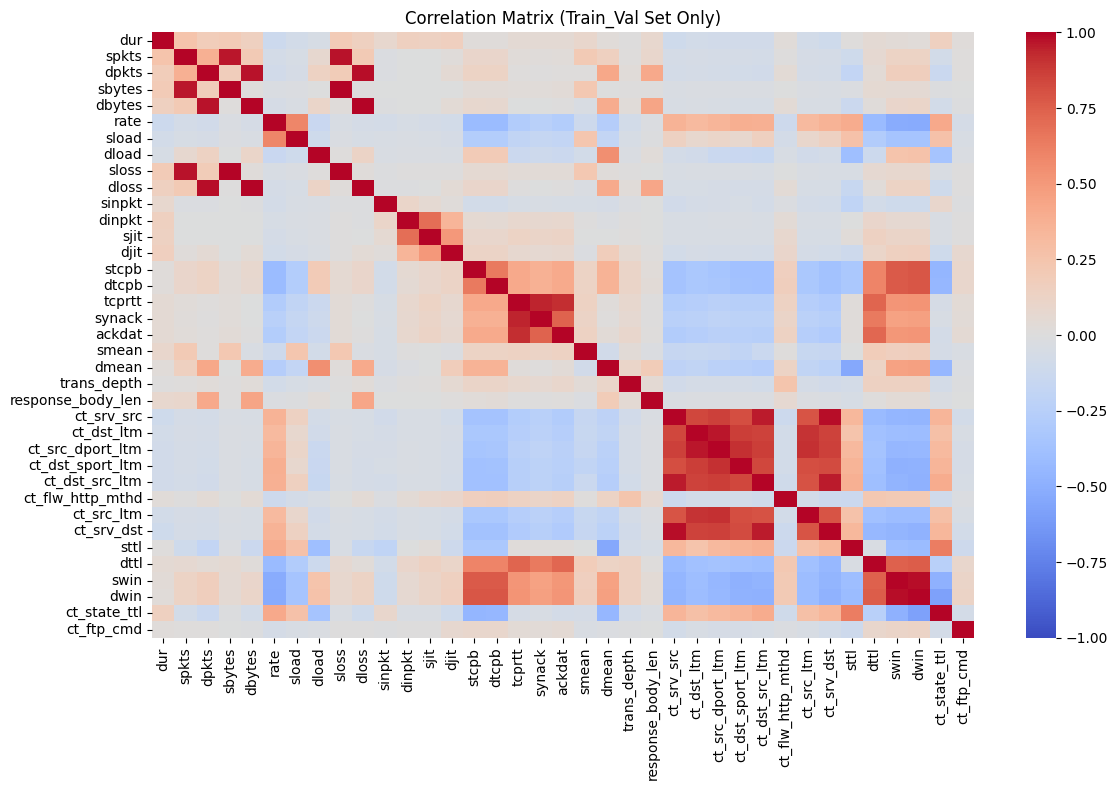

,Feature 1,Feature 2,Correlation
142,dbytes,dloss,0.996776
109,sbytes,sloss,0.995650
77,dpkts,dloss,0.980997
660,swin,dwin,0.980786
581,ct_srv_src,ct_srv_dst,0.979537
72,dpkts,dbytes,0.974870
42,spkts,sloss,0.970319
37,spkts,sbytes,0.962616
588,ct_dst_ltm,ct_src_dport_ltm,0.961602
623,ct_dst_src_ltm,ct_srv_dst,0.960495


In [99]:
# Correlation matrix computed on X_train_knn only
correlation_matrix = X_train_val_knn[numerical_features_knn].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Matrix (Train_Val Set Only)")
plt.tight_layout()
plt.show()

threshold = 0.9
corr_pairs = (correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)).stack().reset_index())
corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]
high_correlations = corr_pairs[corr_pairs["Correlation"].abs() >= threshold].sort_values("Correlation", key=lambda x: x.abs(), ascending=False)
display(high_correlations)

In [100]:
correlating_features = ["dloss", "sloss", "dwin", "dpkts", "ct_srv_src", "spkts", "ct_dst_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm", "ct_src_ltm", "tcprtt"]

X_train_val_knn = X_train_val_knn.drop(columns=correlating_features)
X_test_knn = X_test_knn.drop(columns=correlating_features)

numerical_features_knn = [f for f in numerical_features_knn if f not in correlating_features]

In [101]:
# numeric scales of values: not robust -> scaling for numerical features and one-hot-encoding for categorical features
preprocessor_knn = ColumnTransformer(transformers=[
    ("num", RobustScaler(), numerical_features_knn),  # brings outliers closer to the other values
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

# skewed class distribution: oversample minority classes to 30% of the majority class size.
def sampling_strategy_func(y):
    counts = Counter(y)
    majority_size = max(counts.values())
    return {cls: max(cnt, int(majority_size * 0.3)) for cls, cnt in counts.items()}

# Preprocessing + SMOTE + classifier:
def make_knn_pipeline(n_neighbors):
    return ImbPipeline(steps=[
        ("preprocessor", preprocessor_knn),
        ("smote", SMOTE(random_state=42, sampling_strategy=sampling_strategy_func)),
        ("clf", KNeighborsClassifier(n_neighbors=n_neighbors, weights="distance")),
    ])

In [102]:
# hyperparameter testing via 5-fold stratified cross-validation on X_train_knn/y_train_knn
knn_results = []

for k in [3, 5, 7, 11, 15, 21, 31]:
    pipeline = make_knn_pipeline(k)
    cv_scores = cross_validate(pipeline, X_train_val_knn, y_train_val_knn, cv=cv, scoring=scoring, n_jobs=-1)

    macro_f1_mean, macro_f1_std = cv_scores["test_macro_f1"].mean(), cv_scores["test_macro_f1"].std()
    weighted_f1_mean, weighted_f1_std = cv_scores["test_weighted_f1"].mean(), cv_scores["test_weighted_f1"].std()

    knn_results.append({
        "n_neighbors": k,
        "macro_f1_mean": macro_f1_mean, "macro_f1_std": macro_f1_std,
        "weighted_f1_mean": weighted_f1_mean, "weighted_f1_std": weighted_f1_std,
    })
    print(f"k={k}: macro F1={macro_f1_mean:.3f} (+/-{macro_f1_std:.3f}), weighted F1={weighted_f1_mean:.3f} (+/-{weighted_f1_std:.3f})")

knn_results_df = pd.DataFrame(knn_results)
print(knn_results_df.sort_values("macro_f1_mean", ascending=False))

k=3: macro F1=0.491 (+/-0.005), weighted F1=0.776 (+/-0.001)
k=5: macro F1=0.497 (+/-0.004), weighted F1=0.782 (+/-0.002)
k=7: macro F1=0.496 (+/-0.005), weighted F1=0.783 (+/-0.001)
k=11: macro F1=0.491 (+/-0.005), weighted F1=0.783 (+/-0.002)
k=15: macro F1=0.487 (+/-0.003), weighted F1=0.782 (+/-0.001)
k=21: macro F1=0.484 (+/-0.004), weighted F1=0.781 (+/-0.001)
k=31: macro F1=0.480 (+/-0.004), weighted F1=0.778 (+/-0.002)
   n_neighbors  macro_f1_mean  macro_f1_std  weighted_f1_mean  weighted_f1_std
1            5       0.496611      0.004268          0.781760         0.001634
2            7       0.495609      0.005082          0.783077         0.001315
3           11       0.491308      0.005023          0.782825         0.001601
0            3       0.491288      0.005422          0.776347         0.001369
4           15       0.487103      0.002944          0.782154         0.001212
5           21       0.483723      0.003674          0.780683         0.000705
6           31  

In [103]:
# Refit the best configuration (highest mean cross-validated macro F1) on the full
# training set, so it can be evaluated once on the held-out test set.
best_k = knn_results_df.sort_values("macro_f1_mean", ascending=False).iloc[0]["n_neighbors"]
print("Best k (by CV macro F1):", best_k)

knn_pipeline = make_knn_pipeline(int(best_k))

# Cross-validation performance
y_cv_pred_knn = cross_val_predict(
    knn_pipeline,
    X_train_val_knn,
    y_train_val_knn,
    cv=cv,
    n_jobs=-1
)

print(f"Cross-Validated (out-of-fold) Performance, k={int(best_k)}")
print(classification_report(y_train_val_knn, y_cv_pred_knn))
print("CV macro F1:", f1_score(y_train_val_knn, y_cv_pred_knn, average="macro"))

# Train final model on all training/validation data
knn_pipeline.fit(X_train_val_knn, y_train_val_knn)

Best k (by CV macro F1): 5.0
Cross-Validated (out-of-fold) Performance, k=5
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     83700
           1       0.68      0.75      0.71     12588
           2       0.12      0.08      0.10      2096
           3       0.35      0.42      0.38     14718
           4       0.67      0.65      0.66     40072
           5       0.22      0.15      0.18      2409
           6       0.59      0.53      0.56     21821
           7       0.10      0.52      0.16       157
           8       0.23      0.62      0.33      1360
           9       1.00      0.98      0.99     52984

    accuracy                           0.78    231905
   macro avg       0.48      0.56      0.50    231905
weighted avg       0.79      0.78      0.78    231905

CV macro F1: 0.4965941483891614


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['dur', 'sbytes', 'dbytes',
                                                   'rate', 'sload', 'dload',
                                                   'sinpkt', 'dinpkt', 'sjit',
                                                   'djit', 'stcpb', 'dtcpb',
                                                   'synack', 'ackdat', 'smean',
                                                   'dmean', 'trans_depth',
                                                   'response_body_len',
                                                   'ct_src_dport_ltm',
                                                   'ct_flw_http_mthd',
                                                   'ct_srv_dst', 'sttl', 'dttl',
                                                   'swin', 'ct_state_ttl',
                                                   'ct_ftp_cmd']),
                                                 ('cat',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['proto', 'service', 'state',
                                                   'is_ftp_login',
                                                   'is_sm_ips_ports'])])),
                ('smote',
                 SMOTE(random_state=42,
                       sampling_strategy=<function sampling_strategy_func at 0x00000245F646ECA0>)),
                ('clf', KNeighborsClassifier(weights='distance'))])

In [104]:
# Performance on the training data the model was fit on:
y_train_pred_knn = knn_pipeline.predict(X_train_val_knn)
print("Training Set Performance")
print(classification_report(y_train_val_knn, y_train_pred_knn))

Training Set Performance
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     83700
           1       0.88      0.86      0.87     12588
           2       0.39      0.20      0.27      2096
           3       0.47      0.59      0.53     14718
           4       0.79      0.81      0.80     40072
           5       0.62      0.25      0.36      2409
           6       0.94      0.85      0.89     21821
           7       0.91      0.97      0.94       157
           8       0.98      0.99      0.99      1360
           9       1.00      0.99      1.00     52984

    accuracy                           0.90    231905
   macro avg       0.80      0.75      0.76    231905
weighted avg       0.90      0.90      0.90    231905



In [105]:
# Final, single evaluation on the untouched test set:
y_test_pred_knn = knn_pipeline.predict(X_test_knn)
print("Test Set Performance")
print(classification_report(y_test_knn, y_test_pred_knn))
print("Test macro F1:", f1_score(y_test_knn, y_test_pred_knn, average="macro"))

Test Set Performance
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      9300
           1       0.67      0.75      0.71      1399
           2       0.11      0.07      0.09       233
           3       0.34      0.42      0.38      1635
           4       0.67      0.65      0.66      4453
           5       0.23      0.18      0.20       268
           6       0.60      0.53      0.56      2425
           7       0.12      0.59      0.20        17
           8       0.28      0.72      0.40       151
           9       0.99      0.98      0.99      5887

    accuracy                           0.78     25768
   macro avg       0.49      0.58      0.51     25768
weighted avg       0.79      0.78      0.78     25768

Test macro F1: 0.5071953213901247


In [106]:
### Classification tree
X_train_val_tree = X_train_val.copy()
X_test_tree = X_test.copy()
y_train_val_tree = y_train_val.copy()
y_test_tree = y_test.copy()

In [107]:
# OneHotEncoding for categorical features
preprocessor_tree = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_features),
    # ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

def make_tree_pipeline(ccp_alpha):
    return Pipeline(steps=[
        ("preprocessor", preprocessor_tree),
        ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=42, ccp_alpha=ccp_alpha)),
    ])

# DATA QUALITY ISSUES:
# correlation: robust
# outliers: robust
# numeric scales of values: robust
# skewed class distribution: sensitive -> must be fixed -> class_weight="balanced" -> increases weight of loss function for minority classes

Number of alpha values to try: 10714
[ 0.00000000e+00 -9.75781955e-19 -9.21571847e-19 -7.04731412e-19
 -3.25260652e-19 -1.62630326e-19 -1.62630326e-19 -1.08420217e-19
 -1.08420217e-19 -5.42101086e-20] ... [0.02353296 0.02458767 0.03987883 0.04921462 0.08393437]
    ccp_alpha  train_f1_mean  cv_macro_f1_mean  cv_macro_f1_std
48   0.000041       0.617947          0.580308         0.008872
47   0.000026       0.632891          0.577877         0.009584
46   0.000019       0.645383          0.572799         0.008949
45   0.000016       0.655376          0.569608         0.009815
49   0.000085       0.586080          0.567865         0.007725
44   0.000013       0.662657          0.566667         0.008150
43   0.000012       0.670204          0.566371         0.007938
42   0.000011       0.674970          0.564638         0.006920
39   0.000008       0.691402          0.563667         0.006818
36   0.000007       0.701375          0.563661         0.004414


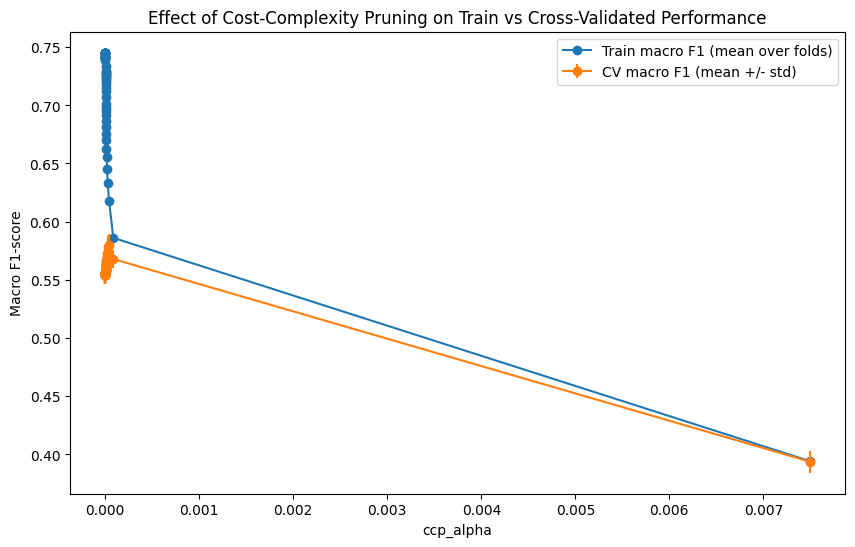

In [108]:
# Candidate alpha values are generated once from a tree fit on the full training data (train_val_tree) for computational reasons
preprocessor_tree_full = ColumnTransformer(transformers=[
    ("num", "passthrough", numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])
X_train_processed_tree_full = preprocessor_tree_full.fit_transform(X_train_val_tree)

tree_full = DecisionTreeClassifier(class_weight="balanced", random_state=42)
path = tree_full.cost_complexity_pruning_path(X_train_processed_tree_full, y_train_val_tree)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Number of alpha values to try: {len(ccp_alphas)}")
print(ccp_alphas[:10], "...", ccp_alphas[-5:])

# Test different alpha values via 5-fold stratified cross-validation: here 50 -> alpha is price for complexity
alphas_to_try = ccp_alphas[::max(1, len(ccp_alphas)//50)]

results = []
for alpha in alphas_to_try:
    pipeline = make_tree_pipeline(alpha)
    cv_scores = cross_validate(pipeline, X_train_val_tree, y_train_val_tree, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=True)

    train_f1_mean = cv_scores["train_macro_f1"].mean()
    val_f1_mean = cv_scores["test_macro_f1"].mean()
    val_f1_std = cv_scores["test_macro_f1"].std()

    results.append({"ccp_alpha": alpha, "train_f1_mean": train_f1_mean, "cv_macro_f1_mean": val_f1_mean, "cv_macro_f1_std": val_f1_std})

results_df = pd.DataFrame(results)
print(results_df.sort_values("cv_macro_f1_mean", ascending=False).head(10))

plt.figure(figsize=(10, 6))
plt.plot(results_df["ccp_alpha"], results_df["train_f1_mean"], marker="o", label="Train macro F1 (mean over folds)")
plt.errorbar(results_df["ccp_alpha"], results_df["cv_macro_f1_mean"], yerr=results_df["cv_macro_f1_std"], marker="o", label="CV macro F1 (mean +/- std)")
plt.xlabel("ccp_alpha")
plt.ylabel("Macro F1-score")
plt.title("Effect of Cost-Complexity Pruning on Train vs Cross-Validated Performance")
plt.legend()
plt.show()

In [109]:
best_alpha = results_df.sort_values("cv_macro_f1_mean", ascending=False).iloc[0]["ccp_alpha"]
print("Best alpha (by CV macro F1):", best_alpha)

tree_pipeline = make_tree_pipeline(best_alpha)

# Cross-validated (out-of-fold) predictions
y_cv_pred_tree = cross_val_predict(
    tree_pipeline,
    X_train_val_tree,
    y_train_val_tree,
    cv=cv,
    n_jobs=-1
)
print(f"\nCross-Validated (out-of-fold) Performance, alpha={best_alpha}")
print(classification_report(y_train_val_tree, y_cv_pred_tree))

print("CV macro F1:", f1_score(y_train_val_tree, y_cv_pred_tree, average="macro"))

tree_pipeline.fit(X_train_val_tree, y_train_val_tree)

print("Train macro F1:", f1_score(y_train_val_tree, tree_pipeline.predict(X_train_val_tree), average="macro"))
print("Number of nodes:", tree_pipeline.named_steps["clf"].tree_.node_count)

Best alpha (by CV macro F1): 4.076751811451094e-05

Cross-Validated (out-of-fold) Performance, alpha=4.076751811451094e-05
              precision    recall  f1-score   support

           0       0.98      0.77      0.87     83700
           1       0.82      0.82      0.82     12588
           2       0.08      0.41      0.13      2096
           3       0.36      0.63      0.46     14718
           4       0.87      0.50      0.64     40072
           5       0.12      0.22      0.16      2409
           6       0.51      0.80      0.62     21821
           7       0.43      0.78      0.55       157
           8       0.42      0.85      0.56      1360
           9       1.00      0.98      0.99     52984

    accuracy                           0.76    231905
   macro avg       0.56      0.68      0.58    231905
weighted avg       0.85      0.76      0.79    231905

CV macro F1: 0.579799599184498
Train macro F1: 0.6188212113434894
Number of nodes: 1219


In [110]:
# Performance on the training data the model was fit on:
y_train_pred_tree = tree_pipeline.predict(X_train_val_tree) 
print("Training Set Performance")
print(classification_report(y_train_val_tree, y_train_pred_tree))

# Final, single evaluation on the untouched test set
y_test_pred_tree = tree_pipeline.predict(X_test_tree)
print("Test Set Performance")
print(classification_report(y_test_tree, y_test_pred_tree))
print("Test macro F1:", f1_score(y_test_tree, y_test_pred_tree, average="macro"))

Training Set Performance
              precision    recall  f1-score   support

           0       0.99      0.76      0.86     83700
           1       0.82      0.83      0.82     12588
           2       0.11      0.46      0.18      2096
           3       0.37      0.75      0.49     14718
           4       0.89      0.51      0.65     40072
           5       0.16      0.24      0.19      2409
           6       0.51      0.82      0.63     21821
           7       0.54      1.00      0.70       157
           8       0.50      1.00      0.66      1360
           9       1.00      0.98      0.99     52984

    accuracy                           0.77    231905
   macro avg       0.59      0.73      0.62    231905
weighted avg       0.86      0.77      0.79    231905

Test Set Performance
              precision    recall  f1-score   support

           0       0.98      0.76      0.86      9300
           1       0.82      0.82      0.82      1399
           2       0.10      0.4

In [111]:
# use attack_category_map.csv to map short feature names to real name, type, description 
# report both training and validation error
# for evaluation use Accuracy, Precision (TP / all positive predicted), Recall (TP / alle tatsächlich Positiven), Specificity (TN / (TN+FP)), F1-score